## Autoencoders 📦

So far we've discussed the basics of CNNs and RNNs and how they are applicable in finding correlations and trends within existing data and trained to **classify** novel data based on these trends.

- Classification is useful in a lot of contexts, but chat models like GPT and image models like Midjourney are generative!

Learning about classification models already exposed us to how we can store these trends in a deep neural network.

Image data can be treated as a multi dimensional vector that exists in some space.

- When we apply a CNN model we are transforming the state space in order to create a derivative vector in a **new latent space**. We are essentially **encoding the data into a new vector space of different dimensionality.**

What would happen if we took the vector in this encoded state space and shifted it a little bit (i.e. found a neighboring vector). Could a completely new data point be generated by sampling a nearby point in this space? After that, could we find a way to decode this new sampled point to generate a synthetic image?

---

An **autoencoder** is a neural network that compresses high dimensional data into a lower level embedding vector (much like MNIST) but then can also decompress any given embedding vector back to the original state space. This network has two parts:

- The **encoder** is responsible for compressing and mapping the high dimensional data into the latent space.

- The **decoder** is responsible for decompressing an embedding vector into the original state space.

These are two different models that we need to train at the same time. We have to have a training pipline that **encodes training data into an embedding, then ensure the embedding aligns with the image's classification, then decodes the image into something that resembles the original image.**

- In the training process the encoder essentially generates a 2d, 3d, n-dimensional *embedding* or representation of the original image. We can then choose points anywhere in that space and then ask the decoder to translate them back into a synthetic image (that was not in the original dataset).

---

## Architecting Encoders and Decoders

To encode data we need to generalize that data.

- The go to way to accomplish this would be to apply several convolutional layers that extract features from the data.

- **In this way the architecture of an encoder is identical to that of a CNN.**

| Layer | Output Shape | # Params |
| ----- | ------------ | -------- |
| Input | (32, 32, 3) | 0 |
| Conv2d | (16, 16, 32) | 896 |
| Conv2d | (8, 8, 64) | 18,496|
| Conv2d | (4, 4, 8) | 4,616 |
| Flatten | (None, 128) | 0 |
| Dense | (128, ) | 16,512 |


So think of the encoder as flattening our final insights into an array of 4616 insights (the reason we flatten is to abstract away the locational relevance of each output from the prior layer).

- The flattening and dense layer steps are both optional but we can explort the relevance once we get to the decoder.

---

### Transposed Convolutions and Upsampling

The decoder architecture needs to accept this linear output and then needs to apply **transpose convolutional layers to undo the affects of the Conv2d layers.**

- If a regular convolution creates a sliding window and sums up dot products to produce a smaller output image, then a transposed convolution takes an image's pixel, and spreads it out into a larger window.

- - If convolution results in downsampling an image, then transposed convolutions are a way of upscaling an image.

Here is an image that shows how the dot product operation is used to multiply each singular input pixel by the learned kernel:

<img src="./media/transposed_convolution_in_action.png" width=800px>

So note how the kernel here in that example has no overlapping regions when applied, and effectively double the size of the input dimensions (from 2 by 2 to 4 by 4). **This occurs because the kernel is applied with a stride of 2, which is the width and height of the kernel.**

- We could alternatively upsample by choosing a stride of one and apply a 3 by 3 kernel to get the same result (a 4 by 4 image)

<img src="./media/transposed_convolution_in_action_2.png" width=800px>

---

### An Aside: Dilation

We have not covered what *dilation* entails, but here is a quick idea.

Suppose some kernel: $K$ with some values

$$K =
\begin{bmatrix}
1 & 2 & 3 \\
4 & 5 & 6 \\
7 & 8 & 9 \\
\end{bmatrix}
$$

- When dilation = 1, the kernel is taken and applied as is.

- When dilation = 2, we insert one gap between each kernal element, i.e. we apply some distancing. So $K$, our applied kernel is transformed as so:

$$K_2 =
\begin{bmatrix}
1 & 0 & 2 & 0 & 3 \\
0 & 0 & 0 & 0 & 0 \\
4 & 0 & 5 & 0 & 6 \\
0 & 0 & 0 & 0 & 0 \\
7 & 0 & 8 & 0 & 9 \\
\end{bmatrix}
$$

The kernel itself still only has 9 real weights but by expanding the receptive field of the kernel the network can "see" a wider portion of the image in one go. The benefits of dilation are as follows:

- Preserves resolution: Unlike pooling or stride, dilation doesn’t shrink the output.

- Efficient: No extra parameters are added.

- Useful in semantic segmentation or time-series modeling.

---

Back to decoders now. Now that we know what type of layer can be applied to construct the decoder lets summarize an architecture that could efficently de-summarize or upscale the flattened representation given by the encoder back into the dimensions of the original input (32, 32, 3)

| Layer | Output Shape | # Params |
| ----- | ------------ | -------- |
| Input | (None, 128) | 0 |
| Dense | (128,) | 16,512 |
| Reshape | (4, 4, 8) | 0 |
| Conv2dTranspose | (8, 8, 64) | 4,672 |
| Conv2dTranspose | (16, 16, 32) | 18, 464 |
| Conv2dTranspose | (32, 32, 3) | 867 |

1) The `Dense` layer initially remaps the flattened input features back into some locational features. 

- - The `Dense(128)` layer learns to structure the data in such a way that, when you reshape it into (4, 4, 8), it mimics the spatial features that the encoder produced before flattening.

2) The `Reshape` layer serves to simply take the 128 outputted features and reconstruct a cuboid stack of kernels from it.

- - Together the `Dense` and `Reshape` layers are learning to reverse the encoder’s final convolution + flatten operations, and reassemble meaningful spatial activations.

3) The sequence of `Conv2dTranspose` layers similarly reverse engineer the effects of the `Conv2d` layers in the encoder. 

- - And most importantly the last `Conv2d` layer returns a classic 32 by 32 image (with the three channels corresponding to RGB). This image is dimensionally identical to the inputs provided to the encoder.

A few **important** disclaimers:

- The **encoder applies two final transformations: a flattening layer followed by a dense layer**. Together, these operations **abstract away spatial structure by converting spatial feature maps into a compact, location-agnostic vector**.

- **If the encoder did not include the dense layer after flattening, then the decoder would not need to include a dense layer either because there would be no learned transformation to reverse.**

- **If the encoder skipped both the flattening and dense layers (i.e., the output of the final convolution was used directly as the latent representation), then the decoder could immediately begin with transposed convolution layers. This would eliminate the need for a dense and reshape layer to undo the effects of flattening and remapping.**

In [2]:
import keras
from keras import layers

# Step 1: Define the encoder and decoder models
encoder_model = keras.Sequential(
    [
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, kernel_size=3, strides=2, padding='same', activation='relu'),
        layers.Conv2D(64, kernel_size=3, strides=2, padding='same', activation='relu'),
        layers.Conv2D(8, kernel_size=3, strides=2, padding='same', activation='relu'),
        layers.Flatten(),
        layers.Dense(128, activation='relu')
    ],
    name="encoder"
)

decoder_model = keras.Sequential(
    [
        layers.Input(shape=(128,)),
        layers.Dense(4 * 4 * 8, activation='relu'),
        layers.Reshape((4, 4, 8)),
        layers.Conv2DTranspose(64, kernel_size=3, strides=2, padding='same', output_padding=1, activation='relu'),
        layers.Conv2DTranspose(32, kernel_size=3, strides=2, padding='same', output_padding=1, activation='relu'),
        layers.Conv2DTranspose(3, kernel_size=3, strides=2, padding='same', output_padding=1, activation='sigmoid')
    ],
    name="decoder"
)

# Step 2: Define the pipeline, create the composite model.

# Define the layer for initial input.
autoencoder_input = layers.Input(shape=(32, 32, 3))

# Connect the pipeline
encoded_output = encoder_model(autoencoder_input)
decoded_output = decoder_model(encoded_output)

# Make a model from the pipeline
autoencoder = keras.Model(inputs=autoencoder_input, outputs=decoded_output, name='autoencoder')

I0000 00:00:1753304177.787098   49991 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5563 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


## Autoencoder Training Procedure

As you may have guessed, an autoencoder involves connecting the encoder and decoder models together in one composite and unified training pipeline.

The initial input flows through the encoder to produce a latent representation. Then the latent representation flows through the decoder to generate a reconstructed output.

- *The latent representation is often labeled as "z"*

- - So the general idea is: `Input -> z -> Output (reconstructed input)`

- **The loss is measured via the difference between the input and the reconstructed input.**

For now lets just run the training procedure using the high level Keras API


In [3]:
import tensorflow as tf

# Step 3: Compile the model
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

# Step 4: Prepare the data
(x_train, _), (x_test, _) = tf.keras.datasets.cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

train_dataset = tf.data.Dataset.from_tensor_slices(x_train).shuffle(10000).batch(64)

autoencoder.fit(
    x_train, x_train, # input = x_train, output to compare against = x_train
    epochs=10,
    batch_size=64,
    shuffle=True,
    validation_data=(x_test, x_test)  # input = x_test, output to compare against = x_test
)



170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


2025-07-23 16:56:41.644575: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 614400000 exceeds 10% of free system memory.
2025-07-23 16:56:42.555254: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 614400000 exceeds 10% of free system memory.
2025-07-23 16:56:43.782902: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 614400000 exceeds 10% of free system memory.
2025-07-23 16:56:45.484911: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 614400000 exceeds 10% of free system memory.
2025-07-23 16:56:46.669177: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 614400000 exceeds 10% of free system memory.


Epoch 1/10


I0000 00:00:1753304213.606150   73216 service.cc:152] XLA service 0x7f7abc007f80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1753304213.606388   73216 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2025-07-23 16:56:53.790812: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1753304214.924584   73216 cuda_dnn.cc:529] Loaded cuDNN version 90501
2025-07-23 16:56:56.300184: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_323', 8 bytes spill stores, 8 bytes spill loads

2025-07-23 16:56:57.534197: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_d

  8/782 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 0.6931  

I0000 00:00:1753304228.973401   73216 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 29ms/step - loss: 0.6335 - val_loss: 0.5922
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - loss: 0.5891 - val_loss: 0.5834
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 0.5818 - val_loss: 0.5811
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 0.5790 - val_loss: 0.5784
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - loss: 0.5772 - val_loss: 0.5781
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - loss: 0.5762 - val_loss: 0.5761
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - loss: 0.5754 - val_loss: 0.5759
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 0.5743 - val_loss: 0.5754
Epoch 9/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 0.5740 - val_loss: 0.5746
Epoch 10/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - loss: 0.5735 - val_loss: 0.5741


## Testing the Autoencoder

In order to test the *quality* of our basic autoencoder we can sample an embedding from the training dataset and then choose another embedding which is relatively close via a random distribution.

- This surrounding embedding represented a vector in 128 dimensional space that is relatively similar in representation to our original embedding.

- We can then parse the neighbor embedding into our decoder to see what sort of image it represents. Ideally, even if this embedding is blurrly it should still vaguely resemble the original input image associated with the original embedding!


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


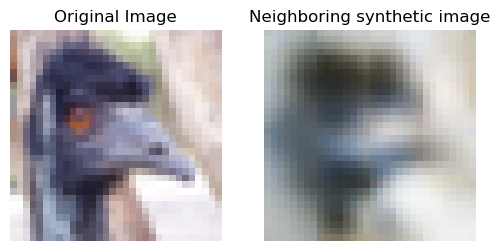

In [44]:
import numpy as np
import matplotlib.pyplot as plt

# Random index
i = np.random.randint(len(x_test))

# Pick a sample and preserve batch shape (1, 32, 32, 3)
sample = np.expand_dims(x_test[i], axis=0)

# Apply the encoder to get the latent representation
sample_embedding = encoder_model.predict(sample)
sample_embedding = sample_embedding[0] # Get the first element in the batch

# Sample a nearby point using a normal distribution
nearby_embedding = sample_embedding + np.random.normal(0, 0.1, size=sample_embedding.shape)

# Decode the nearby embedding
decoded_neighbor = decoder_model.predict(np.expand_dims(nearby_embedding, axis=0))

# Plot original vs decoded-from-perturbed-latent
plt.figure(figsize=(6, 3))

# Original input
plt.subplot(1, 2, 1)
plt.imshow(sample[0])
plt.title("Original Image")
plt.axis("off")

# Neighbor image from perturbed latent
plt.subplot(1, 2, 2)
plt.imshow(decoded_neighbor[0])
plt.title("Neighboring synthetic image")
plt.axis("off")

plt.show()

One problem is that we cannot visualize the latent space, because we cannot visualize 128 dimensions. If our embedding was in 2 or 3 dimensional space we could more easily plot the various embeddings and see clusters form.

- Each embedding could be colorized via its actual label and this would show us what class that image belongs to.

Instead of using this high level embedding what if we used a 2d embedding?

We could implement this by simply adding one extra layer to the encoder and decoder architectures respectively:



In [53]:
import keras
from keras import layers

# Step 1: Define new encoder and decoder models with additional bottleneck for construct 2d embeddings

# --- Encoder ---
encoder_model = keras.Sequential(
    [
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, kernel_size=3, strides=2, padding='same', activation='relu'),
        layers.Conv2D(64, kernel_size=3, strides=2, padding='same', activation='relu'),
        layers.Conv2D(8, kernel_size=3, strides=2, padding='same', activation='relu'),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(2, name="latent_2d")  # ➕ 2D bottleneck
    ],
    name="encoder"
)

# --- Decoder ---
decoder_model = keras.Sequential(
    [
        layers.Input(shape=(2,)),  # 🧠 Now takes 2D bottleneck as input
        layers.Dense(128, activation='relu'),  # ➕ Re-expand to 128D
        layers.Dense(4 * 4 * 8, activation='relu'),
        layers.Reshape((4, 4, 8)),
        layers.Conv2DTranspose(64, kernel_size=3, strides=2, padding='same', output_padding=1, activation='relu'),
        layers.Conv2DTranspose(32, kernel_size=3, strides=2, padding='same', output_padding=1, activation='relu'),
        layers.Conv2DTranspose(3, kernel_size=3, strides=2, padding='same', output_padding=1, activation='sigmoid')
    ],
    name="decoder"
)

# Step 2: Create the pipeline and model
autoencoder_input = layers.Input(shape=(32, 32, 3))
encoded_output = encoder_model(autoencoder_input)
decoded_output = decoder_model(encoded_output)

autoencoder = keras.Model(inputs=autoencoder_input, outputs=decoded_output, name='autoencoder')

# Step 3: Compile the model
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

# Step 4: Prepare the data
(x_train, _), (x_test, _) = tf.keras.datasets.cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

train_dataset = tf.data.Dataset.from_tensor_slices(x_train).shuffle(10000).batch(64)

autoencoder.fit(
    x_train, x_train, # input = x_train, output to compare against = x_train
    epochs=10,
    batch_size=64,
    shuffle=True,
    validation_data=(x_test, x_test)  # input = x_test, output to compare against = x_test
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 34ms/step - loss: 0.6550 - val_loss: 0.6361
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - loss: 0.6355 - val_loss: 0.6356
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - loss: 0.6349 - val_loss: 0.6351
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - loss: 0.6342 - val_loss: 0.6347
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - loss: 0.6343 - val_loss: 0.6344
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - loss: 0.6339 - val_loss: 0.6343
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - loss: 0.6330 - val_loss: 0.6339
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - loss: 0.6332 - val_loss: 0.6340
Epoch 9/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - loss: 0.6328 - val_loss: 0.6335
Epoch 10/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - loss: 0.6320 - val_loss: 0.6342


79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step


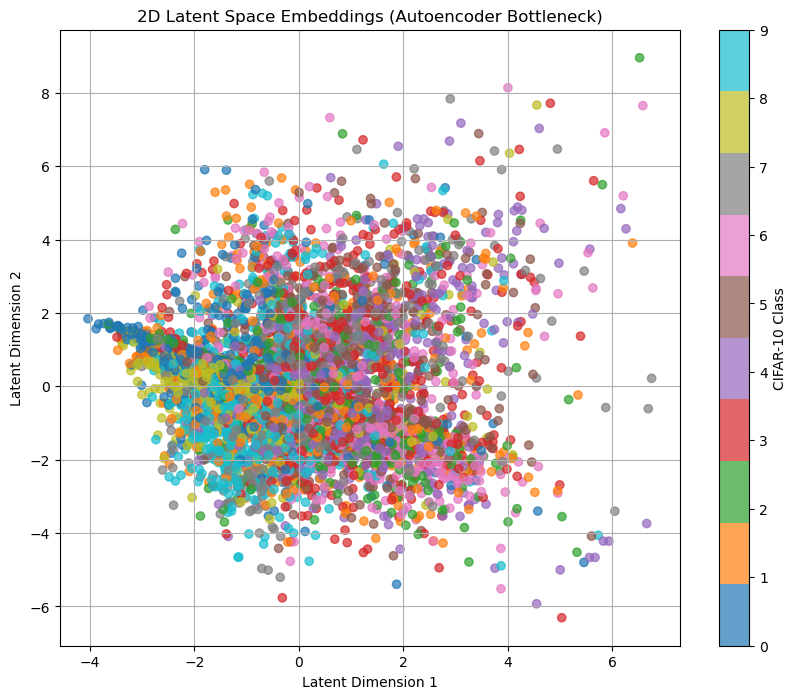

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10

# 1. Load CIFAR-10 test data and normalize
(_, _), (x_test, y_test) = cifar10.load_data()
x_test = x_test.astype("float32") / 255.0
y_test = y_test.flatten()  # For color mapping

# 2. Use encoder_model to get 2D embeddings
embeddings_2d = encoder_model.predict(x_test, batch_size=128)  # shape: (10000, 2)

# 3. Create scatter plot of embeddings
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    embeddings_2d[:, 0], embeddings_2d[:, 1],
    c=y_test,
    cmap='tab10',
    alpha=0.7
)

plt.colorbar(scatter, ticks=range(10), label='CIFAR-10 Class')
plt.title("2D Latent Space Embeddings (Autoencoder Bottleneck)")
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.grid(True)
plt.show()